In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

engine = create_engine("sqlite:///college_debt.db")

df = pd.read_sql("SELECT * FROM colleges", engine)
print(f"Loaded {len(df)} schools")
print(df.columns.tolist())
print(df.head(3))

Loaded 4500 schools
['admission_rate', 'completion_rate', 'median_earnings', 'median_debt', 'student_size', 'school_name', 'state', 'city', 'value_score']
   admission_rate  completion_rate  median_earnings  median_debt  \
0          0.5795           0.2403          40628.0      31000.0   
1          0.8818           0.6423          54501.0      22300.0   
2             NaN           1.0000          37621.0      32189.0   

   student_size                          school_name state        city  \
0        6124.0             Alabama A & M University    AL      Normal   
1       11635.0  University of Alabama at Birmingham    AL  Birmingham   
2         241.0                   Amridge University    AL  Montgomery   

   value_score  
0        1.311  
1        2.444  
2        1.169  


In [2]:
# These are the 4 features we'll use for anomaly detection
features = ['value_score', 'median_debt', 
            'completion_rate', 'admission_rate']

# How many schools have ALL 4 features complete?
df_model = df.dropna(subset=features)
print(f"Schools with complete data: {len(df_model)}")
print(f"Dropped due to missing data: {len(df) - len(df_model)}")

# Quick stats on each feature
print("\nFeature distributions:")
print(df_model[features].describe().round(3))

Schools with complete data: 1521
Dropped due to missing data: 2979

Feature distributions:
       value_score  median_debt  completion_rate  admission_rate
count     1521.000     1521.000         1521.000        1521.000
mean         2.720    22374.178            0.576           0.720
std          1.191     4714.218            0.181           0.222
min          0.889     3500.000            0.000           0.036
25%          2.016    20000.000            0.461           0.614
50%          2.427    23250.000            0.570           0.769
75%          3.014    25874.000            0.695           0.890
max         12.016    40326.000            1.000           1.000


In [3]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

# Scale all features to same range
# Critical step — debt is in $40,000s, value score is 0-10
# Without scaling, debt dominates the model
scaler = StandardScaler()
X = scaler.fit_transform(df_model[features])

print("Features scaled. Sample of scaled values:")
print(pd.DataFrame(X, columns=features).head(3).round(3))

Features scaled. Sample of scaled values:
   value_score  median_debt  completion_rate  admission_rate
0       -1.183        1.830           -1.855          -0.635
1       -0.232       -0.016            0.367           0.729
2        0.221       -0.354            0.370          -0.156


In [4]:
# contamination=0.05 means we expect ~5% of schools to be anomalies
iso = IsolationForest(contamination=0.05, random_state=42)
df_model = df_model.copy()
df_model['anomaly'] = iso.fit_predict(X)

# -1 = anomaly (predatory), 1 = normal
normal = df_model[df_model['anomaly'] == 1]
predatory = df_model[df_model['anomaly'] == -1]

print(f"Normal schools: {len(normal)}")
print(f"Flagged as predatory: {len(predatory)}")
print(f"\nTop 15 flagged schools:")
print(predatory.nsmallest(15, 'value_score')[
    ['school_name', 'state', 'value_score', 
     'median_debt', 'completion_rate']
].to_string())

Normal schools: 1445
Flagged as predatory: 76

Top 15 flagged schools:
                                             school_name state  value_score  median_debt  completion_rate
2296                                    Allen University    SC        0.889      34290.0           0.1331
952                           Grambling State University    LA        1.126      36500.0           0.3616
1821                        Saint Augustine's University    NC        1.204      29669.0           0.2500
202                        Design Institute of San Diego    CA        1.273      36844.0           0.8000
611                             Chicago State University    IL        1.397      30625.0           0.1549
1998                              Wilberforce University    OH        1.447      26468.0           0.1202
1651                                The Juilliard School    NY        1.483      25500.0           0.9256
2447                            Dallas Christian College    TX        1.746      

In [5]:
# Pull ASU's exact numbers
asu = df_model[df_model['school_name'].str.contains('Arizona State', na=False)]
print(asu[['school_name', 'state', 'value_score', 'median_debt', 
           'completion_rate', 'admission_rate', 'student_size']].to_string())

                                     school_name state  value_score  median_debt  completion_rate  admission_rate  student_size
51     Arizona State University Campus Immersion    AZ        3.214      19500.0           0.6804          0.8989       64674.0
3896  Arizona State University Digital Immersion    AZ        3.214      19500.0           0.0000          0.6669       53782.0


In [6]:
print("FLAGGED schools — average metrics:")
print(predatory[features].mean().round(3))

print("\nNORMAL schools — average metrics:")
print(normal[features].mean().round(3))

print("\nDifference (flagged vs normal):")
diff = predatory[features].mean() - normal[features].mean()
print(diff.round(3))

FLAGGED schools — average metrics:
value_score            5.585
median_debt        14105.211
completion_rate        0.627
admission_rate         0.392
dtype: float64

NORMAL schools — average metrics:
value_score            2.569
median_debt        22809.086
completion_rate        0.573
admission_rate         0.737
dtype: float64

Difference (flagged vs normal):
value_score           3.016
median_debt       -8703.875
completion_rate       0.054
admission_rate       -0.345
dtype: float64


Top 10 states with most flagged schools:
  state  flagged_count
0    PR             16
1    CA             10
2    NY              9
3    MA              6
4    IL              4
5    PA              3
6    MO              2
7    AZ              2
8    IN              2
9    TN              2


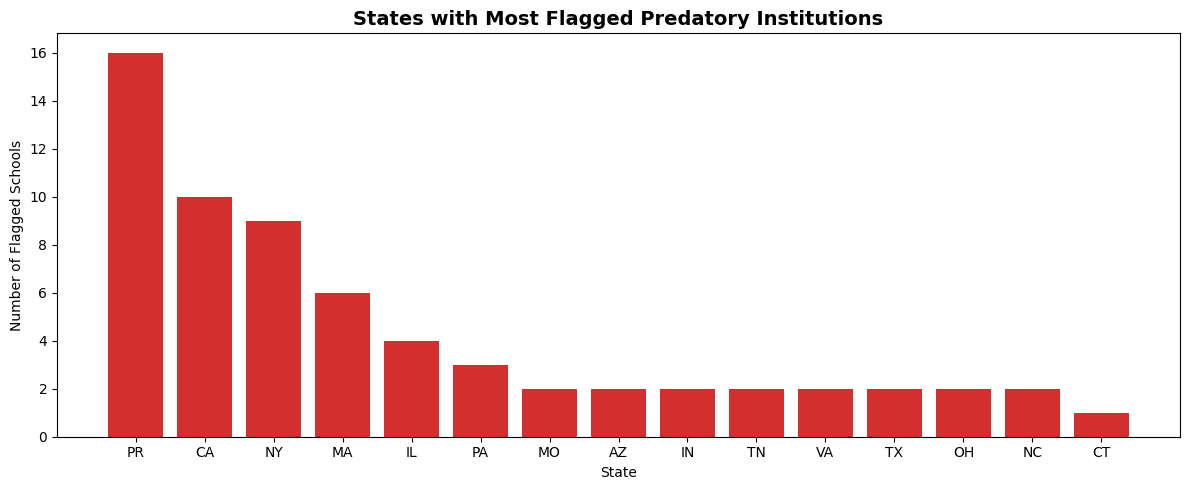

In [7]:
state_flags = predatory.groupby('state').size()\
    .sort_values(ascending=False).reset_index()
state_flags.columns = ['state', 'flagged_count']

print("Top 10 states with most flagged schools:")
print(state_flags.head(10))

# Chart it
plt.figure(figsize=(12, 5))
plt.bar(state_flags.head(15)['state'], 
        state_flags.head(15)['flagged_count'],
        color='#d32f2f')
plt.title('States with Most Flagged Predatory Institutions', 
          fontsize=14, fontweight='bold')
plt.xlabel('State')
plt.ylabel('Number of Flagged Schools')
plt.tight_layout()
plt.show()

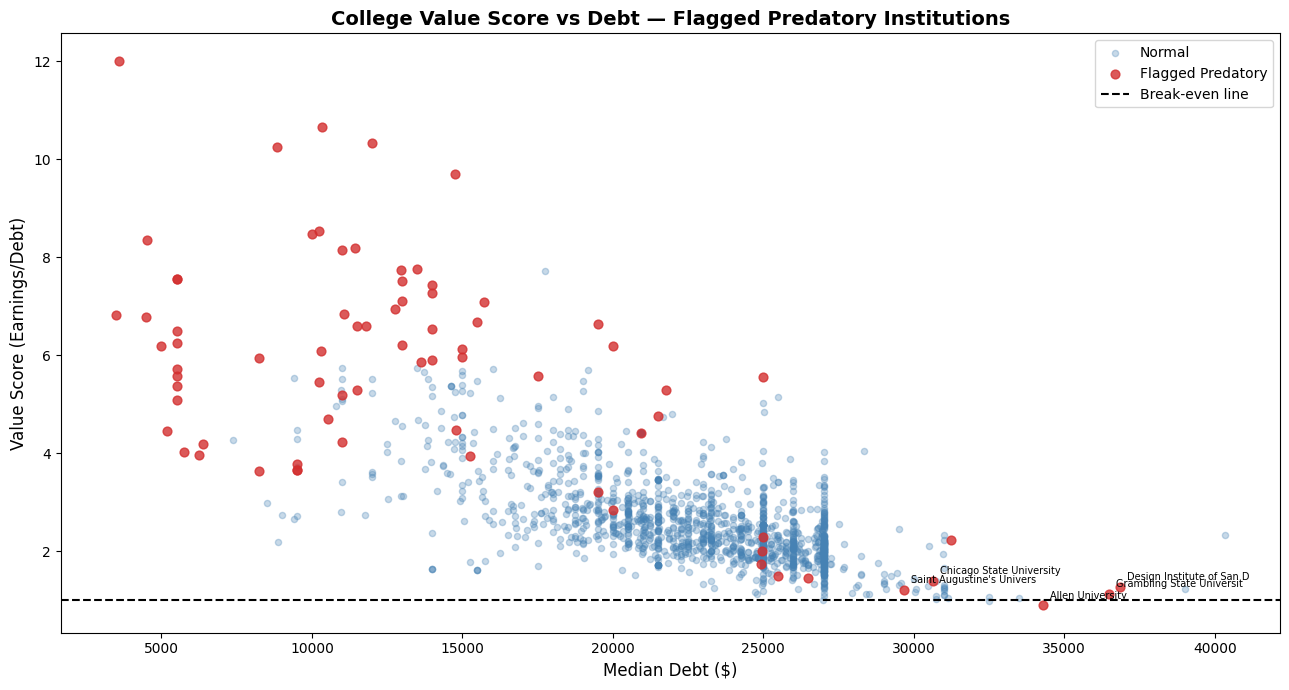

In [8]:
plt.figure(figsize=(13, 7))

# Normal schools
plt.scatter(
    normal['median_debt'], 
    normal['value_score'],
    alpha=0.3, color='steelblue', 
    label='Normal', s=20
)

# Flagged schools
plt.scatter(
    predatory['median_debt'], 
    predatory['value_score'],
    alpha=0.8, color='#d32f2f', 
    label='Flagged Predatory', s=40
)

# Label the most extreme ones
worst_5 = predatory.nsmallest(5, 'value_score')
for _, row in worst_5.iterrows():
    plt.annotate(
        row['school_name'][:25], 
        (row['median_debt'], row['value_score']),
        fontsize=7, 
        xytext=(5, 5),
        textcoords='offset points'
    )

plt.axhline(y=1.0, color='black', linestyle='--', 
            linewidth=1.5, label='Break-even line')
plt.xlabel('Median Debt ($)', fontsize=12)
plt.ylabel('Value Score (Earnings/Debt)', fontsize=12)
plt.title('College Value Score vs Debt — Flagged Predatory Institutions',
          fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
predatory.to_sql("flagged_schools", engine, 
                 if_exists="replace", index=False)
print(f"Saved {len(predatory)} flagged schools to database")

Saved 76 flagged schools to database


## Anomaly Detection — Isolation Forest Results

76 institutions flagged as outliers across 4 dimensions:
value_score, median_debt, completion_rate, admission_rate

Key finding: flagged schools are NOT the most expensive ones.
They cluster in the $5,000–$25,000 debt range — moderate cost
but poor earnings outcomes relative to that cost.

Median debt is the single most differentiating feature between
flagged and normal institutions.

## Important Nuance — ASU Digital Immersion

Arizona State University Digital Immersion was flagged despite
a reasonable value score (3.21) due to a completion rate of 0.000.

This likely reflects a newly launched program with insufficient
graduate data — not predatory outcomes. This finding highlights
a critical limitation: the model cannot distinguish between
genuinely harmful programs and programs with incomplete data.

Recommendation: filter flagged schools by minimum student size
and minimum years of operation before drawing policy conclusions.

## Geographic Bias — Puerto Rico

Puerto Rico has the highest concentration of flagged schools.
This reflects structural economic conditions — lower average
earnings in PR mechanically reduce value scores regardless
of school quality.

The value score metric has geographic bias that must be
acknowledged in any policy application of this analysis.

In [10]:
# Filter out schools with zero or null completion rates
# These are data quality issues not predatory patterns
df_clean_flags = predatory[predatory['completion_rate'] > 0]
print(f"Flagged schools after removing zero completion rate: {len(df_clean_flags)}")

# Also filter minimum student size for data reliability  
df_clean_flags = df_clean_flags[df_clean_flags['student_size'] >= 100]
print(f"After minimum 100 students filter: {len(df_clean_flags)}")

print("\nCleaned flagged school list:")
print(df_clean_flags.nsmallest(15, 'value_score')[
    ['school_name', 'state', 'value_score', 
     'median_debt', 'completion_rate', 'student_size']
].to_string())

Flagged schools after removing zero completion rate: 72
After minimum 100 students filter: 69

Cleaned flagged school list:
                                             school_name state  value_score  median_debt  completion_rate  student_size
2296                                    Allen University    SC        0.889      34290.0           0.1331         576.0
952                           Grambling State University    LA        1.126      36500.0           0.3616        4164.0
1821                        Saint Augustine's University    NC        1.204      29669.0           0.2500         172.0
611                             Chicago State University    IL        1.397      30625.0           0.1549        1384.0
1998                              Wilberforce University    OH        1.447      26468.0           0.1202         822.0
1651                                The Juilliard School    NY        1.483      25500.0           0.9256         468.0
2447                            Dall

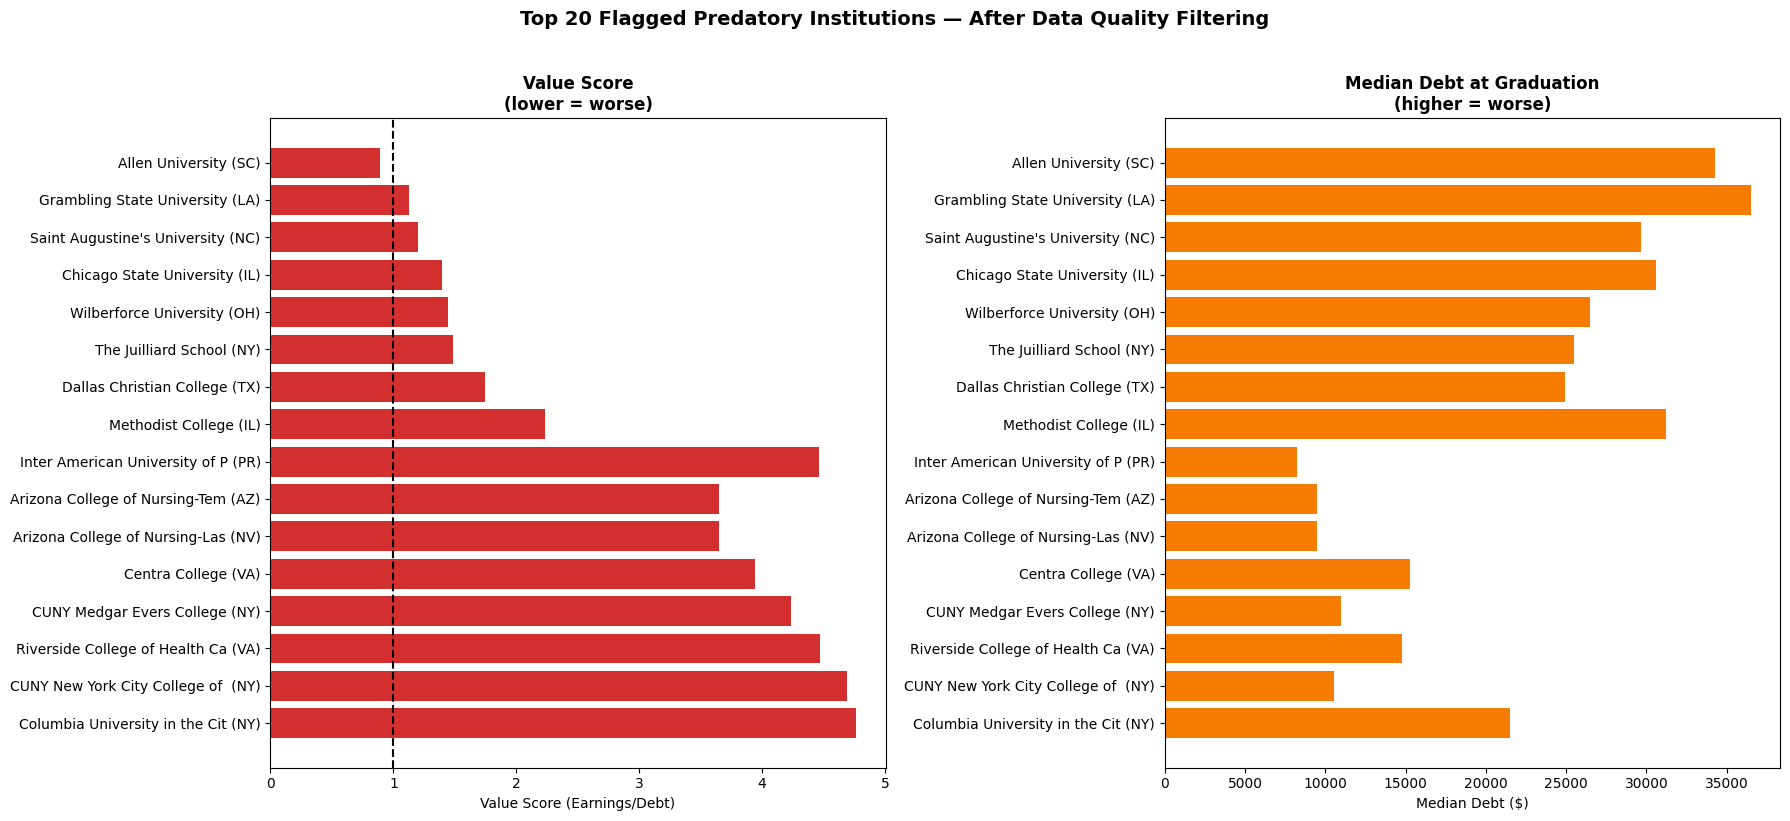

In [11]:
# Final cleaned predatory schools — horizontal bar chart
top_worst = df_clean_flags.nsmallest(20, 'value_score').copy()
top_worst['label'] = top_worst['school_name'].str[:30] + \
                     ' (' + top_worst['state'] + ')'

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Left — value score
axes[0].barh(top_worst['label'], top_worst['value_score'], 
             color='#d32f2f')
axes[0].axvline(x=1.0, color='black', linestyle='--', linewidth=1.5)
axes[0].set_title('Value Score\n(lower = worse)', fontweight='bold')
axes[0].set_xlabel('Value Score (Earnings/Debt)')
axes[0].invert_yaxis()

# Right — median debt
axes[1].barh(top_worst['label'], top_worst['median_debt'], 
             color='#f57c00')
axes[1].set_title('Median Debt at Graduation\n(higher = worse)', 
                  fontweight='bold')
axes[1].set_xlabel('Median Debt ($)')
axes[1].invert_yaxis()

plt.suptitle('Top 20 Flagged Predatory Institutions — After Data Quality Filtering',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [12]:
df_clean_flags.to_sql("flagged_schools_clean", engine, 
                      if_exists="replace", index=False)

print(f"Final cleaned flagged schools saved: {len(df_clean_flags)}")
print("\nProject database tables:")
from sqlalchemy import inspect
inspector = inspect(engine)
for table in inspector.get_table_names():
    count = pd.read_sql(f"SELECT COUNT(*) as n FROM {table}", 
                        engine).iloc[0,0]
    print(f"  {table}: {count} rows")

Final cleaned flagged schools saved: 69

Project database tables:
  colleges: 4500 rows
  flagged_schools: 76 rows
  flagged_schools_clean: 69 rows
